# Objetivo del Análisis Exploratorio de Datos (EDA)

El objetivo de este análisis es comprender la estructura, calidad y características del dataset relacionado con la incontinencia urinaria femenina, con el fin de preparar los datos para un modelo de clasificación multiclase.

En particular, se busca:

- Identificar problemas en los datos (valores nulos, duplicados, tipos incorrectos)
- Entender la distribución de las variables
- Detectar relaciones relevantes entre variables clínicas y el tipo de incontinencia urinaria
- Evaluar la calidad del dataset para modelado predictivo

Este proceso es fundamental en proyectos de inteligencia artificial, especialmente en el ámbito clínico, donde la calidad del dato impacta directamente en la fiabilidad del modelo.

In [1]:
import os
os.getcwd()

'c:\\Users\\Coder\\Desktop\\IA-P6\\proyectos\\Proyecto7_Equipo3_Multiclase\\notebooks\\modeling'

In [2]:
from pathlib import Path

print(Path().resolve())

C:\Users\Coder\Desktop\IA-P6\proyectos\Proyecto7_Equipo3_Multiclase\notebooks\modeling


In [3]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path().resolve().parents[1] 

DATA_PATH = BASE_DIR / "data" / "raw" / "nhanes_ui_women.csv"

print(DATA_PATH) 

df = pd.read_csv(DATA_PATH)
df.head()

C:\Users\Coder\Desktop\IA-P6\proyectos\Proyecto7_Equipo3_Multiclase\data\raw\nhanes_ui_women.csv


,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


## Dimensiones del Dataset

Se analiza el tamaño del dataset en términos de número de filas (observaciones) y columnas (variables).

Esto permite evaluar si el volumen de datos es adecuado para un modelo de machine learning y detectar posibles limitaciones.

In [4]:
df.shape

(9074, 27)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna_vez        9068 non-null   float64
 14  act

## Estadísticas Descriptivas

Se calculan estadísticas descriptivas para todas las variables, incluyendo categóricas.

Esto permite identificar distribuciones, valores extremos y posibles anomalías en los datos.

In [12]:
df.describe(include='all')

,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
count,9074.000000,9074,4.321000e+03,9074.000000,9074.000000,9067.000000,7620.000000,9074.000000,1694.000000,1599.000000,...,3552.000000,6889.000000,1735.000000,6884.000000,1350.000000,4054.000000,2368.000000,4213.000000,9074.000000,9074
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,2017-March2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,none
freq,NaN,4753,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4857
mean,126293.524135,NaN,2.922638e+04,52.077584,3.210712,1.295577,30.471325,1.631475,1.139315,1.176986,...,1.455518,1.537669,1.979251,1.633062,2.010370,1.883818,2.276605,1.614764,0.464734,NaN
std,10512.947934,NaN,2.801757e+04,17.627592,1.097130,1.942076,8.212430,0.542643,0.346377,0.464586,...,0.685566,0.542405,1.040487,0.531325,1.030252,0.407879,1.220828,0.934940,0.498782,NaN
min,109266.000000,NaN,5.397605e-79,20.000000,1.000000,1.000000,11.100000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN
25%,116673.500000,NaN,1.093688e+04,37.000000,3.000000,1.000000,24.600000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,NaN
50%,124146.000000,NaN,2.349353e+04,54.000000,3.000000,1.000000,29.000000,2.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,NaN
75%,136317.000000,NaN,4.080794e+04,67.000000,4.000000,2.000000,34.800000,2.000000,1.000000,1.000000,...,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,2.000000,1.000000,NaN


## Análisis de Valores Nulos

Se identifican los valores faltantes en el dataset, ya que pueden afectar significativamente el análisis y el rendimiento del modelo.

La gestión de valores nulos es especialmente crítica en datasets clínicos, donde la ausencia de información puede no ser aleatoria.

In [13]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls[nulls > 0]

ui_urgencia_frecuencia       7724
medicacion_hta_cicloL        7475
medicacion_hta_cicloP        7380
ui_esfuerzo_frecuencia       7339
ui_molestia_percibida        6706
ui_cantidad                  5522
ui_otro_tipo_presente        5020
ui_impacto_actividades       4861
peso_encuesta                4753
actividad_fisica_vigorosa    4321
ui_urgencia_presente         2190
ui_esfuerzo_presente         2185
ui_frecuencia                2180
imc                          1454
nivel_pobreza_familiar        905
pais_nacimiento                 7
fumadora_alguna_vez             6
dtype: int64

## Detección de Registros Duplicados

Se identifican registros duplicados que podrían sesgar el análisis y afectar el entrenamiento del modelo.

En datasets clínicos, los duplicados pueden representar errores de registro o múltiples entradas del mismo paciente.

In [14]:
duplicates = df.duplicated().sum()
print(f"Duplicados encontrados: {duplicates}")

df = df.drop_duplicates()

Duplicados encontrados: 0


## Corrección de Tipos de Datos

Se identificaron variables que, aunque están codificadas como numéricas (`float64`), representan categorías binarias o etiquetas clínicas.

Estas variables se convierten a tipo categórico para:

- Mejorar la interpretación del análisis
- Evitar errores en modelos de machine learning
- Alinear el dataset con su significado clínico real

In [11]:
df.dtypes

id_participante              float64
ciclo_nhanes                     str
peso_encuesta                float64
edad_anios                   float64
etnia                        float64
pais_nacimiento              float64
imc                          float64
dx_hipertension              float64
medicacion_hta_cicloP        float64
medicacion_hta_cicloL        float64
dx_diabetes                  float64
dx_cancer                    float64
dx_artritis                  float64
fumadora_alguna_vez          float64
actividad_fisica_vigorosa    float64
nivel_pobreza_familiar       float64
ui_frecuencia                float64
ui_cantidad                  float64
ui_esfuerzo_presente         float64
ui_esfuerzo_frecuencia       float64
ui_urgencia_presente         float64
ui_urgencia_frecuencia       float64
ui_otro_tipo_presente        float64
ui_molestia_percibida        float64
ui_impacto_actividades       float64
target_tiene_ui                int64
target_tipo_ui                   str
d

In [15]:
# Variables binarias
cols_binarias = [
    'dx_hipertension',
    'medicacion_hta_cicloP',
    'medicacion_hta_cicloL',
    'dx_diabetes',
    'dx_cancer',
    'dx_artritis',
    'fumadora_alguna_vez',
    'actividad_fisica_vigorosa',
    'ui_esfuerzo_presente',
    'ui_urgencia_presente',
    'ui_otro_tipo_presente',
    'target_tiene_ui'
]

# Variables categóricas adicionales
cols_categoricas = ['etnia', 'pais_nacimiento', 'target_tipo_ui']

# Conversión
for col in cols_binarias + cols_categoricas:
    df[col] = df[col].astype('category')

df.dtypes

id_participante               float64
ciclo_nhanes                      str
peso_encuesta                 float64
edad_anios                    float64
etnia                        category
pais_nacimiento              category
imc                           float64
dx_hipertension              category
medicacion_hta_cicloP        category
medicacion_hta_cicloL        category
dx_diabetes                  category
dx_cancer                    category
dx_artritis                  category
fumadora_alguna_vez          category
actividad_fisica_vigorosa    category
nivel_pobreza_familiar        float64
ui_frecuencia                 float64
ui_cantidad                   float64
ui_esfuerzo_presente         category
ui_esfuerzo_frecuencia        float64
ui_urgencia_presente         category
ui_urgencia_frecuencia        float64
ui_otro_tipo_presente        category
ui_molestia_percibida         float64
ui_impacto_actividades        float64
target_tiene_ui              category
target_tipo_

## Conclusiones de la Limpieza de Datos

Tras la fase de limpieza, se obtuvo un dataset:

- Libre de duplicados
- Con tipos de datos correctamente definidos
- Preparado para análisis exploratorio y modelado

Se identificó que múltiples variables clínicas estaban codificadas como numéricas, lo que podría haber inducido errores en el análisis. Su correcta transformación a variables categóricas mejora la calidad del estudio.

Este proceso garantiza una base sólida para el desarrollo de modelos de clasificación multiclase en el contexto clínico.

## Distribución de la Variable Objetivo

Se analiza la distribución de la variable objetivo `target_tipo_ui`, que representa los diferentes tipos de incontinencia urinaria.

Este análisis es crítico en problemas de clasificación multiclase, ya que permite:

- Detectar desbalance de clases
- Evaluar la dificultad del problema
- Anticipar posibles problemas en el entrenamiento del modelo

En datasets clínicos, el desbalance de clases es común y puede sesgar los modelos hacia las clases mayoritarias.

In [16]:
# Conteo de clases
class_counts = df['target_tipo_ui'].value_counts()

# Proporciones
class_proportions = df['target_tipo_ui'].value_counts(normalize=True) * 100

class_counts, class_proportions

(target_tipo_ui
 none      4857
 mixed     1642
 stress    1586
 urge       932
 other       57
 Name: count, dtype: int64,
 target_tipo_ui
 none      53.526559
 mixed     18.095658
 stress    17.478510
 urge      10.271104
 other      0.628168
 Name: proportion, dtype: float64)

## Visualización de la Distribución de Clases

Se representa gráficamente la distribución de la variable objetivo para facilitar su interpretación.

La visualización permite identificar de forma inmediata si existe desbalance entre clases.

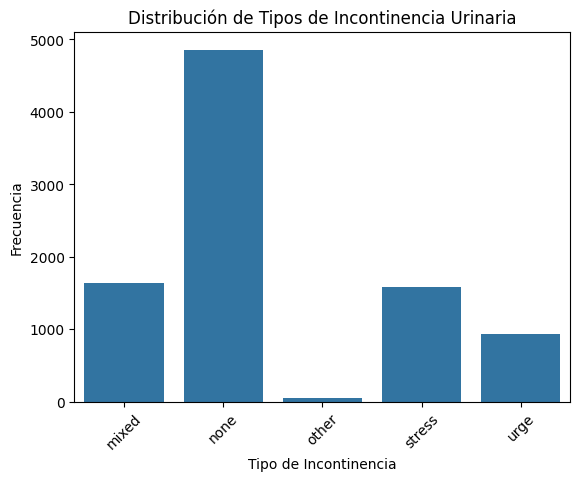

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.countplot(data=df, x='target_tipo_ui')

plt.title('Distribución de Tipos de Incontinencia Urinaria')
plt.xticks(rotation=45)
plt.xlabel('Tipo de Incontinencia')
plt.ylabel('Frecuencia')

plt.show()

## Interpretación de la Distribución

Se observa que:

- Existen diferencias en la frecuencia de las clases
- Algunas categorías presentan menor representación

Esto sugiere la presencia de desbalance de clases, lo cual puede afectar el rendimiento del modelo, favoreciendo las clases mayoritarias.

En consecuencia, será necesario considerar técnicas de balanceo como:

- Oversampling (SMOTE)
- Undersampling
- Uso de métricas adecuadas (F1-score, recall por clase)

In [18]:
df['target_tiene_ui'].value_counts(normalize=True) * 100

target_tiene_ui
0    53.526559
1    46.473441
Name: proportion, dtype: float64

Adicionalmente, se analiza la variable binaria `target_tiene_ui`, que indica la presencia o ausencia de incontinencia urinaria.

Esto permite entender la prevalencia general del problema en la población estudiada.

## Se construye una tabla resumen para facilitar la interpretación cuantitativa de la distribución de clases.

In [19]:
# Tabla resumen combinada
summary = pd.DataFrame({
    'Frecuencia': class_counts,
    'Porcentaje (%)': class_proportions.round(2)
})

summary

,Frecuencia,Porcentaje (%)
target_tipo_ui,,
none,4857,53.53
mixed,1642,18.10
stress,1586,17.48
urge,932,10.27
other,57,0.63


## Análisis Univariado

En esta etapa se analiza cada variable de forma individual para comprender su distribución y características principales.

Este análisis permite:

- Detectar posibles anomalías o valores extremos
- Entender la distribución de variables clínicas relevantes
- Identificar patrones iniciales en los datos

Se realiza un análisis diferenciado según el tipo de variable:

- Variables numéricas → histogramas
- Variables categóricas → conteos de frecuencia

### Análisis de Variables Numéricas

Se analizan variables numéricas clave como edad e IMC, ya que tienen relevancia clínica en la incontinencia urinaria.

Estas variables pueden influir directamente en la aparición y tipo de incontinencia.

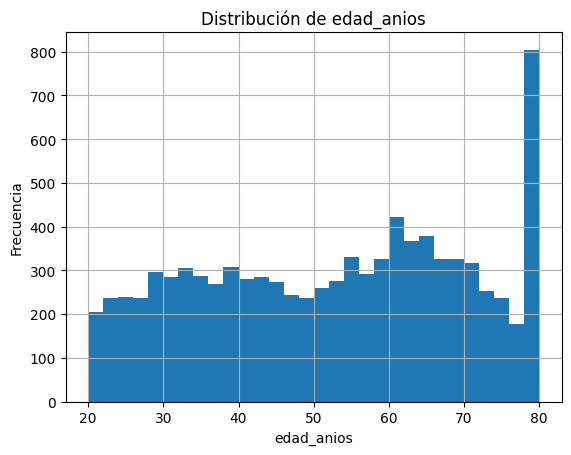

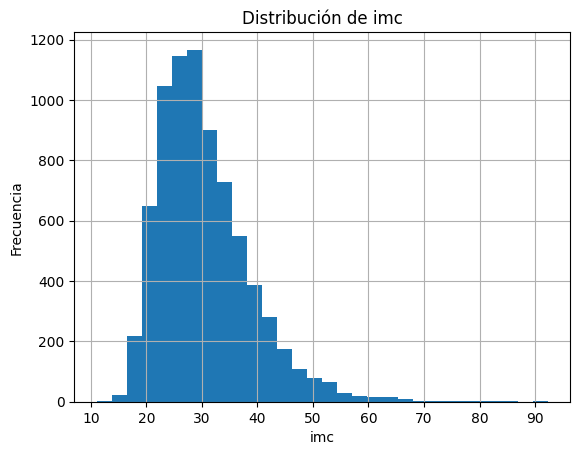

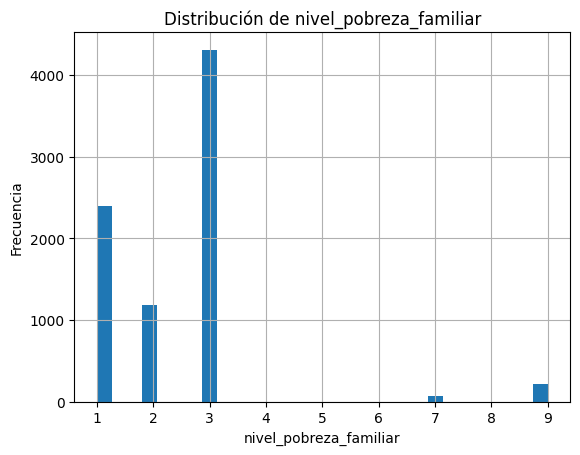

In [20]:
import matplotlib.pyplot as plt

cols_numericas = ['edad_anios', 'imc', 'nivel_pobreza_familiar']

for col in cols_numericas:
    plt.figure()
    df[col].hist(bins=30)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

### Interpretación de Variables Numéricas

- Edad: Permite identificar si la incontinencia es más frecuente en grupos etarios específicos.
- IMC: Puede estar asociado a factores de riesgo como obesidad.
- Nivel de pobreza: Puede reflejar determinantes sociales de salud.

Se evaluará la presencia de sesgos en la distribución y posibles valores extremos.

## Matriz de Correlación

Se analiza la correlación entre variables numéricas para identificar relaciones lineales y posibles redundancias.

Esto permite reducir dimensionalidad y evitar multicolinealidad en el modelo.

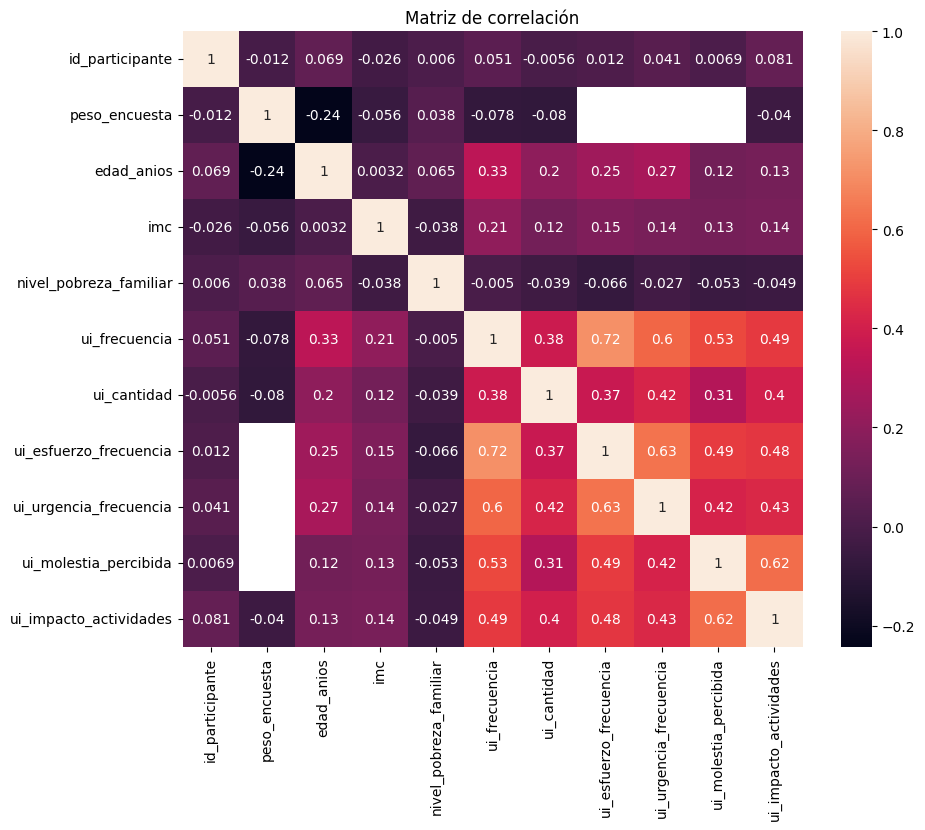

In [23]:
import numpy as np

# Seleccionar solo numéricas reales
df_num = df.select_dtypes(include=['float64'])

# Correlación
corr = df_num.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)
plt.title('Matriz de correlación')
plt.show()

In [24]:
df_corr = df.copy()

# Convertir categorías a numérico temporalmente
for col in df_corr.select_dtypes(['category']).columns:
    df_corr[col] = df_corr[col].cat.codes

corr = df_corr.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr)
plt.title('Matriz de correlación completa')
plt.show()

ValueError: could not convert string to float: '2017-March2020'